In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Data points
X = np.random.rand(10)*5
Y = np.random.rand(10)*5
X = np.sort(X)
Y = np.sort(Y)

# Stack the design matrix with a column of ones (for the intercept)
#CHANGED TO ZEROS
A = np.vstack([X, np.zeros(len(X))]).T

print("X: ",X)
print("Y: ",Y)
print("A: ",A)

X:  [0.12571672 1.20979243 1.94193098 2.2325592  2.62117739 2.83205964
 3.05199028 3.43214313 4.15885755 4.39626971]
Y:  [0.45313605 1.38246438 1.78518641 2.07210486 2.35822382 3.36115007
 4.04170315 4.34568659 4.3864416  4.83416978]
A:  [[0.12571672 0.        ]
 [1.20979243 0.        ]
 [1.94193098 0.        ]
 [2.2325592  0.        ]
 [2.62117739 0.        ]
 [2.83205964 0.        ]
 [3.05199028 0.        ]
 [3.43214313 0.        ]
 [4.15885755 0.        ]
 [4.39626971 0.        ]]


In [7]:
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")
Y2 = m*X+c

Slope: 1.1137595595912055, Intercept: 0.0


In [8]:
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)
# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)
# Step 3: Use the coefficients to predict y-values (polynomial function)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
print(polynomial)

Polynomial Coefficients:  [-0.12164969  0.88303438 -0.58998453  0.60851865]
         3         2
-0.1216 x + 0.883 x - 0.59 x + 0.6085


In [9]:
y_pred = polynomial(X)

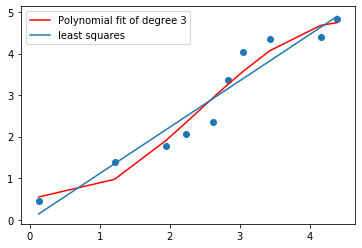

In [10]:
plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.scatter(X,Y)
plt.plot(X,Y2, label = "least squares")
plt.legend()
plt.show()

In [11]:
mse = np.mean((Y - y_pred)**2)
print(f'Mean Squared Error POLYNOMIAL: {mse:.4f}')

mse = np.mean((Y - Y2)**2)
print(f'Mean Squared Error LEAST SQUARES: {mse:.4f}')

Mean Squared Error POLYNOMIAL: 0.0998
Mean Squared Error LEAST SQUARES: 0.1522


In [13]:
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared POLYNOMIAL: {r_squared:.4f}')

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - Y2)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared LEAST SQUARES: {r_squared:.4f}')

R-squared POLYNOMIAL: 0.9503
R-squared LEAST SQUARES: 0.9242
